# EDA
I will load the data and to EDA (Exploratory Data Analysis)

## Setup

### Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Data

In [2]:
files = ["h20201332", "h20211332", "h20221331", "h20231331", "h20241331"]
dfs = []
for file in files:
    data = pd.read_csv(f"../data/{file}data.csv")
    data["file"] = file
    dfs.append(data)
    print(f"File: {file}, Shape: {data.shape}")

df = pd.concat(dfs, ignore_index=True)
print(f"Merged shape: {df.shape}")

File: h20201332, Shape: (10836, 46)
File: h20211332, Shape: (11554, 46)
File: h20221331, Shape: (10404, 46)
File: h20231331, Shape: (8832, 46)
File: h20241331, Shape: (8315, 46)
Merged shape: (49941, 46)


In [3]:
df.head()

,pk_teuna_fikt,sug_tik,THUM_GEOGRAFI,SUG_DEREH,SEMEL_YISHUV,REHOV1,REHOV2,BAYIT,ZOMET_IRONI,KVISH1,...,KIVUN_HAZIYA,MAHOZ,NAFA,EZOR_TIVI,MAAMAD_MINIZIPALI,ZURAT_ISHUV,STATUS_IGUN,X,Y,file
0,2020000003,1,1,3,0,NaN,NaN,NaN,NaN,461.0,...,9,5,51,512,99.0,99.0,1,185093.0,660450.0,h20201332
1,2020000009,1,1,1,6500,602.0,609.0,NaN,210007.0,NaN,...,1,3,32,324,0.0,14.0,1,192948.0,704662.0,h20201332
2,2020000014,1,1,1,8300,970.0,NaN,NaN,NaN,NaN,...,9,4,44,442,0.0,13.0,3,175302.0,655930.0,h20201332
3,2020000035,1,1,1,7900,424.0,304.0,NaN,9850054.0,NaN,...,9,4,42,422,0.0,13.0,1,190940.0,665512.0,h20201332
4,2020000043,1,1,2,8400,363.0,NaN,80.0,NaN,NaN,...,1,4,44,441,0.0,14.0,1,181573.0,644722.0,h20201332


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49941 entries, 0 to 49940
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pk_teuna_fikt      49941 non-null  int64  
 1   sug_tik            49941 non-null  int64  
 2   THUM_GEOGRAFI      49941 non-null  int64  
 3   SUG_DEREH          49941 non-null  int64  
 4   SEMEL_YISHUV       49941 non-null  int64  
 5   REHOV1             31231 non-null  float64
 6   REHOV2             15591 non-null  float64
 7   BAYIT              17446 non-null  float64
 8   ZOMET_IRONI        15591 non-null  float64
 9   KVISH1             16398 non-null  float64
 10  KVISH2             16153 non-null  float64
 11  KM                 16353 non-null  float64
 12  ZOMET_LO_IRONI     6520 non-null   float64
 13  YEHIDA             49941 non-null  int64  
 14  SHNAT_TEUNA        49941 non-null  int64  
 15  HODESH_TEUNA       49941 non-null  int64  
 16  SHAA               49941 non-null

## Data Dictionary

Based on the local codebook files and [Codebook](https://www.cbs.gov.il/he/publications/DocLib1/2015/PUF/%D7%AA%D7%97%D7%91%D7%95%D7%A8%D7%94/H20131162AccCodebook.pdf)



| Field | Meaning | Notes |
|---|---|---|
| `PK_TEUNA_FIKT` | Synthetic accident identifier | |
| `SUG_TIK` | Accident file type | Describes police-investigated road accidents with casualties |
| `THUM_GEOGRAFI` | Geographic area | Israel excluding Judea and Samaria, or Judea and Samaria |
| `SUG_DEREH` | Road type | Combines urban/non-urban and intersection/non-intersection |
| `SEMEL_YISHUV` | Locality code | Referenced against the official locality list |
| `REHOV1` | Primary street code | Available only for urban roads (`SUG_DEREH` 1 or 2) |
| `REHOV2` | Secondary street code | Available only for urban roads (`SUG_DEREH` 1 or 2) |
| `BAYIT` | House number | Named `MISPAR_BAIT` in the codebook. Available only for urban roads not at an intersection (`SUG_DEREH = 2`) |
| `ZOMET_IRONI` | Urban intersection code | Available only for urban intersections (`SUG_DEREH = 1`) |
| `KVISH1` | Primary non-urban road number | Available only for non-urban roads (`SUG_DEREH` 3 or 4) |
| `KVISH2` | Secondary non-urban road number | Available only for non-urban roads (`SUG_DEREH` 3 or 4) |
| `KM` | Kilometer marker | For non-urban locations. When the hundreds-of-meters value is unknown, it is marked accordingly in the source data |
| `ZOMET_LO_IRONI` | Non-urban intersection code | Available only for non-urban intersections (`SUG_DEREH = 3`) |
| `YEHIDA` | Police unit | |
| `SHNAT_TEUNA` | Accident year | |
| `HODESH_TEUNA` | Accident month | |
| `SHAA` | Accident hour | |
| `SUG_YOM` | Day type | Computed from the Hebrew calendar and classified as holiday, holiday eve, intermediate festival day, or other day |
| `YOM_LAYLA` | Day / night | Computed according to daylight and darkness hours for that date |
| `YOM_BASHAVUA` | Day of week | |
| `HUMRAT_TEUNA` | Accident severity | Target field: Fatal, Serious, or Slight |
| `SUG_TEUNA` | Accident type | |
| `HAD_MASLUL` | Single-carriageway configuration | Alternative to `RAV_MASLUL`. When this field contains the applicable configuration, `RAV_MASLUL` is set to `0` |
| `RAV_MASLUL` | Multi-carriageway / median configuration | Alternative to `HAD_MASLUL`. When this field contains the applicable configuration, `HAD_MASLUL` is set to `0` |
| `MEHIRUT_MUTERET` | Permitted speed | `0` means Unknown |
| `TKINUT` | Road condition | `0` means Unknown |
| `ROHAV` | Road width | `0` means Unknown |
| `SIMUN_TIMRUR` | Road markings / traffic signs condition | |
| `TEURA` | Lighting conditions | Includes explicit unknown day/night categories |
| `MEZEG_AVIR` | Weather conditions | |
| `PNE_KVISH` | Road surface condition | |
| `SUG_EZEM` | Type of stationary object struck | Applicable only when `SUG_TEUNA = 8` (collision with stationary object) |
| `MERHAK_EZEM` | Distance of stationary object from road | Applicable only when `SUG_TEUNA = 8` |
| `LO_HAZA` | Pedestrian activity when not crossing | Applicable only when `SUG_TEUNA = 1`. Alternative to `OFEN_HAZIYA` |
| `OFEN_HAZIYA` | Pedestrian crossing behavior | Applicable only when `SUG_TEUNA = 1`. Alternative to `LO_HAZA` |
| `MEKOM_HAZIYA` | Pedestrian crossing location | Applicable only when `SUG_TEUNA = 1` |
| `KIVUN_HAZIYA` | Pedestrian crossing direction | Applicable only when `SUG_TEUNA = 1` |
| `MAHOZ` | District | Available only for urban roads (`SUG_DEREH` 1 or 2) |
| `NAFA` | Subdistrict | Available only for urban roads (`SUG_DEREH` 1 or 2) |
| `EZOR_TIVI` | Natural region | Available only for urban roads (`SUG_DEREH` 1 or 2) |
| `MAAMAD_MINIZIPALI` | Municipal status | Available only for urban roads (`SUG_DEREH` 1 or 2) |
| `ZURAT_ISHUV` | Locality type | Available only for urban roads (`SUG_DEREH` 1 or 2) |
| `STATUS_IGUN` | Geocoding quality | Named `IGUN_MEKUBAZ` in the codebook |
| `X` | X coordinate | Named `X_KORDINAT` in the codebook |
| `Y` | Y coordinate | Named `Y_KORDINAT` in the codebook |
| `file` | Source file | Identifies the yearly source file in the combined dataset; not a field described in the CBS codebook |

### Values Mapping

In [5]:
VALUE_LABELS = {
    "SUG_TIK": {
        1: "Road accident"
    },

    "THUM_GEOGRAFI": {
        1: "Israel, excluding Judea and Samaria",
        2: "Judea and Samaria",
    },

    "SUG_DEREH": {
        1: "Urban, at intersection",
        2: "Urban, not at intersection",
        3: "Non-urban, at intersection",
        4: "Non-urban, not at intersection",
    },

    "YEHIDA": {
        11: "Hof Area (Haifa)",
        12: "Galilee Area",
        14: "Valleys Area",
        20: "Tel Aviv Area",
        33: "Eilat Area",
        34: "Negev Area",
        36: "Shimshon Area (until 1999)",
        37: "Shimshon Area (from 2004)",
        38: "Lachish Area",
        41: "Samaria Area",
        43: "Judea Area",
        51: "Sharon Area",
        52: "Shfela Area",
        61: "Jerusalem District",
    },

    "SUG_YOM": {
        1: "Holiday",
        2: "Holiday eve",
        3: "Intermediate festival day",
        4: "Other day",
    },

    "YOM_LAYLA": {
        1: "Day",
        5: "Night",
    },

    "YOM_BASHAVUA": {
        1: "Sunday",
        2: "Monday",
        3: "Tuesday",
        4: "Wednesday",
        5: "Thursday",
        6: "Friday",
        7: "Saturday",
    },

    "RAMZOR": {
        0: "No",
        1: "Yes",
        9: "Unknown",
    },

    "HUMRAT_TEUNA": {
        1: "Fatal",
        2: "Serious",
        3: "Slight",
    },

    "SUG_TEUNA": {
        1: "Collision with pedestrian",
        2: "Front-to-side collision",
        3: "Front-to-rear collision",
        4: "Side-to-side collision",
        5: "Head-on collision",
        6: "Collision with stopped vehicle, not parked",
        7: "Collision with parked vehicle",
        8: "Collision with stationary object",
        9: "Leaving roadway or mounting sidewalk",
        10: "Rollover",
        11: "Skidding",
        12: "Injury to passenger inside vehicle",
        13: "Fall from moving vehicle",
        14: "Fire",
        15: "Other",
        17: "Rear-to-front collision",
        18: "Rear-to-side collision",
        19: "Collision with animal",
        20: "Struck by vehicle cargo",
    },

    "ZURAT_DEREH": {
        1: "Entrance to interchange",
        2: "Exit from interchange",
        3: "Parking lot / gas station",
        4: "Steep grade",
        5: "Sharp curve",
        6: "Bridge / tunnel",
        7: "Railway crossing",
        8: "Straight road / intersection",
        9: "Other",
        10: "Bus stop / public transport lane",
    },

    "HAD_MASLUL": {
        0: "Not applicable - see RAV_MASLUL",
        1: "One-way",
        2: "Two-way with continuous dividing line",
        3: "Two-way without continuous dividing line",
        4: "Other",
        9: "Number of carriageways unknown",
    },

    "RAV_MASLUL": {
        0: "Not applicable - see HAD_MASLUL",
        1: "Median marked with paint",
        2: "Median with safety barrier",
        3: "Built median without safety barrier",
        4: "Unbuilt median",
        5: "Other",
    },

    "MEHIRUT_MUTERET": {
        0: "Unknown",
        1: "Up to 50 km/h",
        2: "60 km/h",
        3: "70 km/h",
        4: "80 km/h",
        5: "90 km/h",
        6: "100 km/h",
        7: "110 km/h",
        8: "120 km/h",
    },

    "TKINUT": {
        0: "Unknown",
        1: "No defect",
        2: "Poor shoulders",
        3: "Damaged road surface",
        4: "Poor shoulders and damaged road surface",
    },

    "ROHAV": {
        0: "Unknown",
        1: "Up to 5 m",
        2: "5 to 7 m",
        3: "7 to 10.5 m",
        4: "10.5 to 14 m",
        5: "Over 14 m",
    },

    "SIMUN_TIMRUR": {
        1: "Road markings defective or missing",
        2: "Traffic signs defective or missing",
        3: "No defect",
        4: "Traffic sign not required",
        5: "Unknown",
    },

    "TEURA": {
        1: "Normal daylight",
        2: "Limited visibility due to weather",
        3: "Night, lighting operational",
        4: "Lighting exists but defective or not operating",
        5: "Night, no lighting",
        6: "Night, unknown",
        7: "Night, proper lighting with limited visibility",
        8: "Night, defective lighting with limited visibility",
        9: "Night, no lighting with limited visibility",
        10: "Twilight",
        11: "Day, unknown",
    },

    "BAKARA": {
        1: "No control",
        2: "Traffic light functioning",
        3: "Flashing yellow traffic light",
        4: "Traffic light not functioning",
        5: "Stop sign",
        6: "Yield sign",
        7: "Other",
    },

    "MEZEG_AVIR": {
        1: "Clear",
        2: "Rainy",
        3: "Hot and dry",
        4: "Foggy",
        5: "Other",
        9: "Unknown",
    },

    "PNE_KVISH": {
        1: "Dry",
        2: "Wet",
        3: "Covered with fuel",
        4: "Covered with mud",
        5: "Sand or gravel on road",
        6: "Other",
        9: "Unknown",
    },

    "SUG_EZEM": {
        1: "Tree",
        2: "Utility pole",
        3: "Traffic sign / signboard",
        4: "Bridge and protective structures",
        5: "Structure",
        6: "Vehicle safety barrier",
        7: "Barrel",
        8: "Other",
        9: "Unknown",
    },

    "MERHAK_EZEM": {
        1: "Up to 1 m",
        2: "1 to 3 m",
        3: "On the road",
        4: "On the median",
        5: "Other",
        9: "Unknown",
    },

    "LO_HAZA": {
        1: "Walking in direction of traffic",
        2: "Walking against traffic",
        3: "Playing on the road",
        4: "Standing on the road",
        5: "On a traffic island / median",
        6: "On the shoulder / sidewalk",
        7: "Other",
        9: "Unknown",
    },

    "OFEN_HAZIYA": {
        1: "Darted into the road",
        2: "Crossed while obscured",
        3: "Crossed normally",
        4: "Other",
        8: "Did not cross",
        9: "Unknown whether crossed",
    },

    "MEKOM_HAZIYA": {
        1: "Not at crosswalk, near intersection",
        2: "Not at crosswalk, not near intersection",
        3: "At crosswalk without traffic light",
        4: "At crosswalk with traffic light",
        9: "Crossing location unknown",
    },

    "KIVUN_HAZIYA": {
        1: "Right to left",
        2: "Left to right",
        9: "Unknown",
    },

    "IGUN_MEKUBAZ": {
        1: "Precise geocoding",
        2: "Locality center",
        3: "Road center",
        4: "Kilometer marker center",
        9: "Not geocoded",
    },
}

## Split to train and test
I have 2 options:
- option 1: take all the data and split it between train and test
- option 2: take the years 2000-2003 as train data and 2004 as test data and it will be kind of "predicting" the future events

I will start with option 2 for now and will check how the data is looks balanced


I will not create validation data and use cross-validation since I don't have a lot of data

In [6]:
TARGET = "HUMRAT_TEUNA"
YEAR = "SHNAT_TEUNA"

TRAIN_YEARS = [2020, 2021, 2022, 2023]
TEST_YEARS = [2024]

train_df = df[df[YEAR].isin(TRAIN_YEARS)].copy()
test_df = df[df[YEAR].isin(TEST_YEARS)].copy()

now I will do check the split data to make sure the data is split correctly

In [7]:
print(f"Train: {len(train_df):,} ({len(train_df) / len(df):.1%})")
print(f"Test:  {len(test_df):,} ({len(test_df) / len(df):.1%})")

Train: 41,626 (83.4%)
Test:  8,315 (16.6%)


In [9]:
def target_distribution(data):
    labels = data["HUMRAT_TEUNA"].map(
        VALUE_LABELS["HUMRAT_TEUNA"]
    )

    return pd.DataFrame({
        "count": labels.value_counts(),
        "percentage": labels.value_counts(normalize=True) * 100
    }).round(2)

target_comparison = pd.concat(
    {
        "Development": target_distribution(train_df)["percentage"],
        "Test": target_distribution(test_df)["percentage"]
    },
    axis=1
)

target_comparison

,Development,Test
HUMRAT_TEUNA,,
Slight,75.78,65.64
Serious,21.14,29.49
Fatal,3.07,4.87


In [10]:
yearly_target_distribution = (
    pd.crosstab(
        train_df["SHNAT_TEUNA"],
        train_df["HUMRAT_TEUNA"],
        normalize="index"
    )
    .mul(100)
    .rename(columns=VALUE_LABELS["HUMRAT_TEUNA"])
)

yearly_target_distribution.round(2)

HUMRAT_TEUNA,Fatal,Serious,Slight
SHNAT_TEUNA,,,
2020,2.64,17.52,79.84
2021,2.91,19.11,77.98
2022,3.07,22.30,74.63
2023,3.83,26.88,69.29


In [11]:
pd.crosstab(
    train_df["SHNAT_TEUNA"],
    train_df["HUMRAT_TEUNA"]
).rename(columns=VALUE_LABELS["HUMRAT_TEUNA"])

HUMRAT_TEUNA,Fatal,Serious,Slight
SHNAT_TEUNA,,,
2020,286,1899,8651
2021,336,2208,9010
2022,319,2320,7765
2023,338,2374,6120


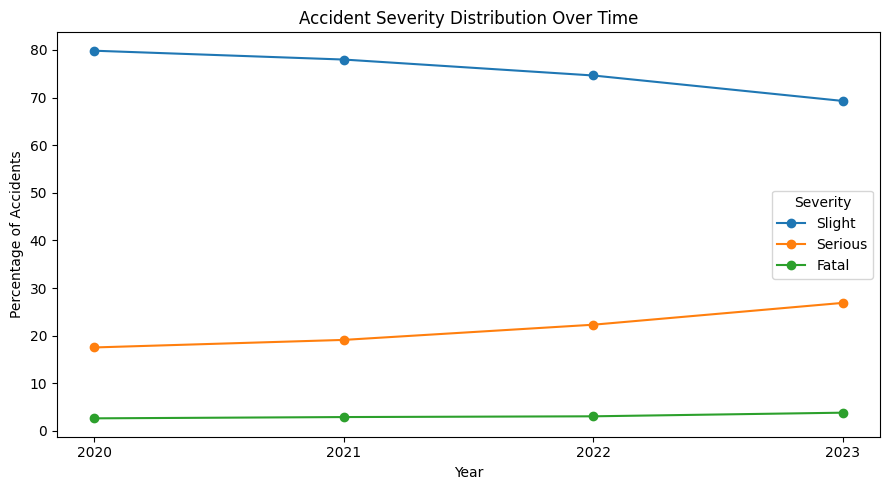

In [12]:
yearly_target_distribution = (
    pd.crosstab(
        train_df["SHNAT_TEUNA"],
        train_df["HUMRAT_TEUNA"],
        normalize="index"
    )
    .mul(100)
    .rename(columns=VALUE_LABELS["HUMRAT_TEUNA"])
)

yearly_target_distribution[
    ["Slight", "Serious", "Fatal"]
].plot(
    kind="line",
    marker="o",
    figsize=(9, 5)
)

plt.title("Accident Severity Distribution Over Time")
plt.xlabel("Year")
plt.ylabel("Percentage of Accidents")
plt.xticks(yearly_target_distribution.index)
plt.legend(title="Severity")

plt.tight_layout()
plt.show()

In [13]:
missing_comparison = pd.DataFrame({
    "development_missing_%": train_df.isna().mean() * 100,
    "test_missing_%": test_df.isna().mean() * 100
})

missing_comparison["difference"] = (
    missing_comparison["test_missing_%"]
    - missing_comparison["development_missing_%"]
)

missing_comparison[missing_comparison["difference"] != 0].sort_values(
    "difference",
    key=abs,
    ascending=False
).round(2)

,development_missing_%,test_missing_%,difference
ZOMET_LO_IRONI,87.31,85.10,-2.21
KVISH1,67.45,65.76,-1.69
KVISH2,67.93,66.29,-1.64
KM,67.50,66.01,-1.49
ZOMET_IRONI,68.58,69.80,1.22
REHOV2,68.58,69.80,1.22
REHOV1,37.39,37.81,0.42
Y,0.22,0.26,0.04
X,0.22,0.26,0.04
BAYIT,65.06,65.10,0.04


In [15]:
def find_unseen_categories(train_data, test_data):
    results = []

    for col in train_data.columns:
        if train_data[col].nunique() < 100:
            train_values = set(train_data[col].dropna().unique())
            test_values = set(test_data[col].dropna().unique())

            unseen = test_values - train_values

            if unseen:
                results.append({
                    "column": col,
                    "unseen_values": unseen
                })

    return pd.DataFrame(results)
find_unseen_categories(train_df, test_df)

,column,unseen_values
0,SHNAT_TEUNA,{2024}
1,MAAMAD_MINIZIPALI,{78.0}
2,ZURAT_ISHUV,{51.0}
3,file,{h20241331}


### Split Observations

#### Target Distribution

The target distribution changes over time.

The proportion of serious and fatal accidents increases between 2020 and 2024, while the proportion of slight accidents decreases.

This temporal distribution shift makes the 2024 test set more challenging, but also provides a more realistic evaluation of the model's ability to generalize to future data.

#### Null Values

There is no significant difference in the percentage of null values between the train and test sets.

Most fields show almost no difference, and the largest differences are approximately 2%.

This suggests that there is no substantial missing-data drift between the train data and the 2024 test set.

#### Unseen Values

I checked for values that appear in the 2024 test set but do not appear in the 2020–2023 train data.

Four unseen values were found:

- `SHNAT_TEUNA = 2024` is expected because 2024 is reserved exclusively for the test set.
- `file = h20241331` is also expected because it identifies the 2024 source file.
- `MAAMAD_MINIZIPALI = 78.0` appears only in the test set.
- `ZURAT_ISHUV = 51.0` appears only in the test set.

The last two unseen categorical values will need to be handled during preprocessing.

## Data Overview

In [16]:
rows = []
for col in train_df.columns:
    non_null = train_df[col].dropna()

    sample_values = (
        non_null.astype(str)
        .drop_duplicates()
        .head(5)
        .tolist()
    )

    rows.append({
        "column": col,
        "dtype": str(train_df[col].dtype),
        "unique": train_df[col].nunique(dropna=True),
        "missing_count": train_df[col].isna().sum(),
        "missing_%": round(train_df[col].isna().mean() * 100, 2),
        "sample_values": sample_values,
    })

statistics = pd.DataFrame(rows)
statistics


,column,dtype,unique,missing_count,missing_%,sample_values
0,pk_teuna_fikt,int64,41626,0,0.00,"[2020000003, 2020000009, 2020000014, 202000003..."
1,sug_tik,int64,1,0,0.00,[1]
2,THUM_GEOGRAFI,int64,2,0,0.00,"[1, 2]"
3,SUG_DEREH,int64,4,0,0.00,"[3, 1, 2, 4]"
4,SEMEL_YISHUV,int64,555,0,0.00,"[0, 6500, 8300, 7900, 8400]"
5,REHOV1,float64,2052,15566,37.39,"[602.0, 970.0, 424.0, 363.0, 1135.0]"
6,REHOV2,float64,1749,28546,68.58,"[609.0, 304.0, 905.0, 426.0, 2465.0]"
7,BAYIT,float64,266,27082,65.06,"[80.0, 140.0, 9999.0, 2.0, 90.0]"
8,ZOMET_IRONI,float64,5177,28546,68.58,"[210007.0, 9850054.0, 30051.0, 80230093.0, 149..."
9,KVISH1,float64,524,28075,67.45,"[461.0, 444.0, 85.0, 5803.0, 3875.0]"


## Features Review

### EDA Helper Functions

Reusable helper functions for analyzing categorical features and their relationship with accident severity.

#### `validate_value_labels`

Validates that all coded values in a feature have a corresponding entry in `VALUE_LABELS`.

This helps detect missing or incomplete label mappings before running the EDA.

In [17]:
def validate_value_labels(df, feature):
    raw_values = set(df[feature].dropna().unique())
    mapped_values = set(VALUE_LABELS[feature].keys())

    unmapped = raw_values - mapped_values

    if unmapped:
        raise ValueError(
            f"{feature} contains unmapped values: {unmapped}"
        )

#### `feature_distribution`

Calculates the distribution of a categorical feature.

Returns the count and percentage of observations for each labeled category.
Optional values can be excluded from the analysis.

In [84]:
def feature_distribution(df, feature, skip_validation=False):
    if feature not in df.columns:
        raise KeyError(f"Column {feature!r} was not found in the DataFrame.")

    data = df[feature]

    mapping = VALUE_LABELS.get(feature)

    if mapping is not None:
        # Replace known codes while preserving values missing from the mapping
        labels = data.replace(mapping)
    else:
        # The feature already contains readable values
        labels = data.copy()

    counts = labels.value_counts(dropna=False)

    summary = counts.rename_axis(feature).reset_index(name="count")
    summary["percentage"] = (
        summary["count"] / len(df) * 100
    ).round(2)

    return summary

#### `severity_summary`

Summarizes accident severity for each category of a feature.

Returns the number of observations and the percentage of Fatal, Serious, Slight, and combined Severe accidents for each category.

In [75]:
def severity_summary(df, feature, exclude_values=None, skip_validation=False):
    exclude_values = exclude_values or []

    data = df[
        ~df[feature].isin(exclude_values)
    ].copy()

    if not skip_validation:
        validate_value_labels(data, feature)

    if feature in VALUE_LABELS:
            feature_labels = data[feature].map(VALUE_LABELS[feature])
    else:
        # Derived features already contain readable labels
        feature_labels = data[feature]
    

    severity_labels = data["HUMRAT_TEUNA"].map(
        VALUE_LABELS["HUMRAT_TEUNA"]
    )

    analysis_df = pd.DataFrame({
        "feature": feature_labels,
        "severity": severity_labels
    })

    summary = (
        analysis_df
        .groupby("feature", dropna=False)
        .agg(
            count=("severity", "size"),
            fatal_rate=(
                "severity",
                lambda x: (x == "Fatal").mean() * 100
            ),
            serious_rate=(
                "severity",
                lambda x: (x == "Serious").mean() * 100
            ),
            slight_rate=(
                "severity",
                lambda x: (x == "Slight").mean() * 100
            )
        )
    )

    summary["severe_rate"] = (
        summary["fatal_rate"]
        + summary["serious_rate"]
    )

    return (
        summary
        .sort_values("severe_rate", ascending=False)
        .round(2)
    )

#### `plot_severity_by_feature`

Visualizes the distribution of accident severity across categories of a feature.

Creates a stacked bar chart showing the percentage of Slight, Serious, and Fatal accidents for each category.

In [20]:
def plot_severity_by_feature(
    df,
    feature,
    display_name=None,
    exclude_values=None,
    figsize=(10, 6)
):
    exclude_values = exclude_values or []
    display_name = display_name or feature

    data = df[
        ~df[feature].isin(exclude_values)
    ].copy()

    validate_value_labels(data, feature)

    feature_labels = data[feature].map(
        VALUE_LABELS[feature]
    )

    severity_labels = data["HUMRAT_TEUNA"].map(
        VALUE_LABELS["HUMRAT_TEUNA"]
    )

    severity_distribution = (
        pd.crosstab(
            feature_labels,
            severity_labels,
            normalize="index"
        ) * 100
    )

    severity_distribution = severity_distribution[
        ["Slight", "Serious", "Fatal"]
    ]

    severity_distribution.plot(
        kind="bar",
        stacked=True,
        figsize=figsize
    )

    plt.title(
        f"Accident Severity Distribution by {display_name}"
    )
    plt.xlabel(display_name)
    plt.ylabel("Percentage of Accidents")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Severity")

    plt.tight_layout()
    plt.show()

### HUMRAT_TEUNA (accident severity) - Target feature
Our target feature is HUMRAT_TEUNA, which mean the accident severity based on the other features

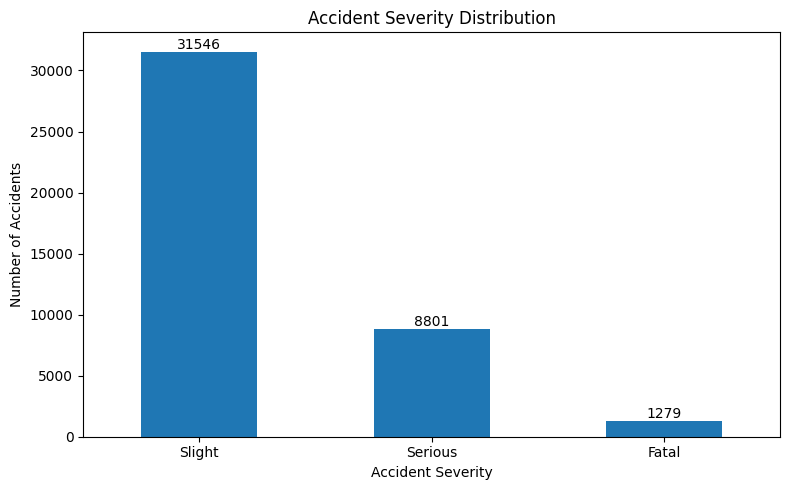

In [21]:
severity_counts = (
    train_df["HUMRAT_TEUNA"]
    .map(VALUE_LABELS["HUMRAT_TEUNA"])
    .value_counts()
)

ax = severity_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Accident Severity Distribution")
ax.set_xlabel("Accident Severity")
ax.set_ylabel("Number of Accidents")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

In [22]:
severity_distribution = pd.DataFrame({
    "count": severity_counts,
    "percentage": severity_counts / severity_counts.sum() * 100
})

severity_distribution.round(2)

,count,percentage
HUMRAT_TEUNA,,
Slight,31546,75.78
Serious,8801,21.14
Fatal,1279,3.07


The target is imbalanced, with slight accidents representing the majority of cases.
Fatal accidents account for only 3.37% of the dataset, so accuracy alone will not be
a sufficient evaluation metric. Macro F1 and per-class precision/recall will be used.

### SUG_TEUNA (Accident Type)


First, I will review the accident types we have

In [23]:
feature_distribution(train_df, "SUG_TEUNA")

,count,percentage
SUG_TEUNA,,
Front-to-side collision,15772,37.89
Collision with pedestrian,9502,22.83
Side-to-side collision,3668,8.81
Front-to-rear collision,3568,8.57
Head-on collision,3142,7.55
Collision with stationary object,1795,4.31
Skidding,1073,2.58
Rollover,1053,2.53
Other,533,1.28


Front-to-side collision and Collision with pedestrian are represent almost 61% of the accidents

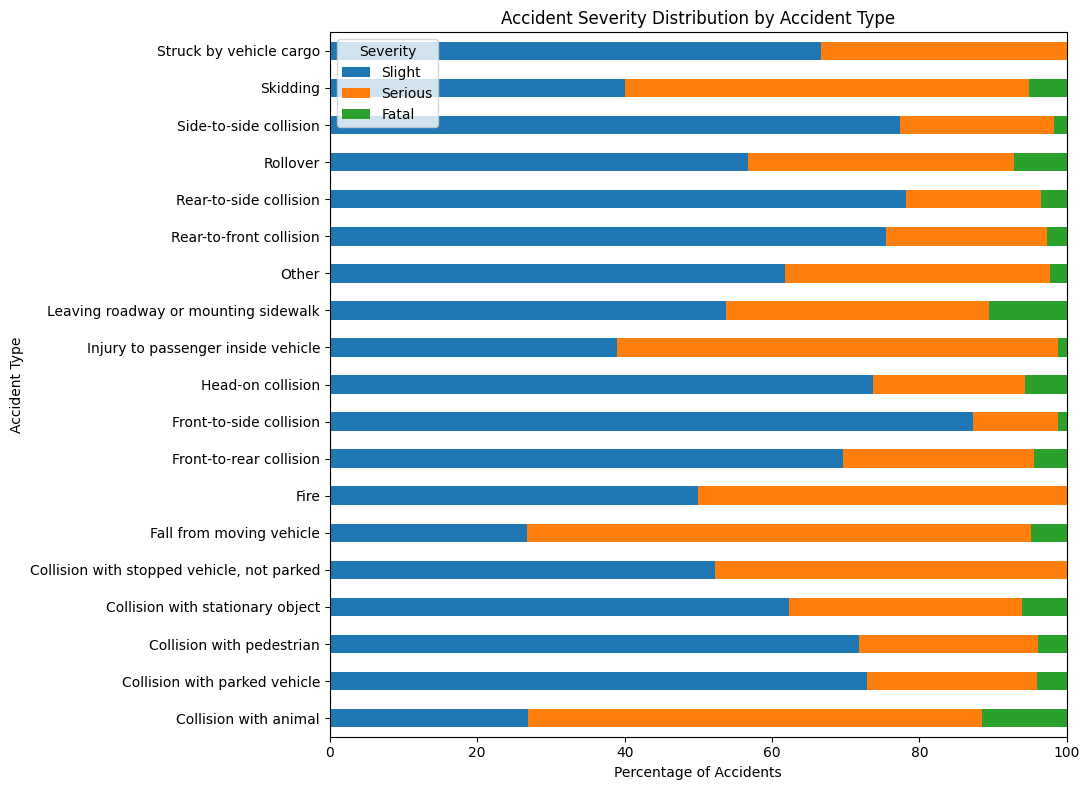

In [24]:
analysis_df = train_df.assign(
    accident_type=train_df["SUG_TEUNA"].map(VALUE_LABELS["SUG_TEUNA"]),
    severity=train_df["HUMRAT_TEUNA"].map(VALUE_LABELS["HUMRAT_TEUNA"])
)

severity_by_type = (
    pd.crosstab(
        analysis_df["accident_type"],
        analysis_df["severity"],
        normalize="index"
    ) * 100
)

severity_by_type = severity_by_type[
    ["Slight", "Serious", "Fatal"]
]

severity_by_type.plot(
    kind="barh",
    stacked=True,
    figsize=(11, 8)
)

plt.title("Accident Severity Distribution by Accident Type")
plt.xlabel("Percentage of Accidents")
plt.ylabel("Accident Type")
plt.legend(title="Severity")

plt.tight_layout()
plt.show()

The following table show us the relation between the accident type to the accident severity.
Each row represent:
- accident_type
- count: how many accident of this type
- fatal_rate: how many of them classified as fatal
- serious_rate: how many of them classified as serious
- slight_rate: how many of them classified as serious
- severe_rate: accidents that wasn't classified as slight (fatal_rate + serious_rate)

In [25]:
type_counts = pd.crosstab(
    analysis_df["accident_type"],
    analysis_df["severity"]
).reindex(columns=["Slight", "Serious", "Fatal"], fill_value=0)

type_summary = type_counts.copy()
type_summary["count"] = type_counts.sum(axis=1)

# Percentage of all dataset rows belonging to each accident type
type_summary["type_percentage"] = (
    type_summary["count"] / len(analysis_df) * 100
)

for severity in ["fatal", "serious", "slight"]:
    type_summary[f"{severity}_rate"] = (
        type_counts[severity.capitalize()]
        / type_summary["count"]
        * 100
    )

type_summary["severe_rate"] = (
    type_summary["fatal_rate"]
    + type_summary["serious_rate"]
)

type_summary = type_summary[
    [
        "count",
        "type_percentage",
        "fatal_rate",
        "serious_rate",
        "slight_rate",
        "severe_rate",
    ]
]

type_summary.sort_values(
    "severe_rate",
    ascending=False
).round(2)

severity,count,type_percentage,fatal_rate,serious_rate,slight_rate,severe_rate
accident_type,,,,,,
Fall from moving vehicle,183,0.44,4.92,68.31,26.78,73.22
Collision with animal,26,0.06,11.54,61.54,26.92,73.08
Injury to passenger inside vehicle,347,0.83,1.15,59.94,38.90,61.10
Skidding,1073,2.58,5.13,54.80,40.07,59.93
Fire,2,0.00,0.00,50.00,50.00,50.00
"Collision with stopped vehicle, not parked",44,0.11,0.00,47.73,52.27,47.73
Leaving roadway or mounting sidewalk,227,0.55,10.57,35.68,53.74,46.26
Rollover,1053,2.53,7.12,36.18,56.70,43.30
Other,533,1.28,2.25,36.02,61.73,38.27


We can see high correlation between the accident type and the severity 
Some insights from this table:
- Collision with animal have high severe_rate, but they also have very low amount of accidents (0.06%)
- Other high severe rate are: Fall from moving vehicle (183 rows)
- Front-to-side collision, Rear-to-side collision, Side-to-side collision and Rear-to-front collision are usually cause to light accident severity

### MEHIRUT_MUTERET (Permitted Speed)


In [26]:
train_df["MEHIRUT_MUTERET"].map(
    VALUE_LABELS["MEHIRUT_MUTERET"]
).value_counts(dropna=False)

feature_distribution(train_df, "MEHIRUT_MUTERET")

,count,percentage
MEHIRUT_MUTERET,,
Up to 50 km/h,24535,58.94
80 km/h,4340,10.43
Unknown,4257,10.23
90 km/h,3831,9.20
70 km/h,2314,5.56
60 km/h,1670,4.01
100 km/h,320,0.77
110 km/h,243,0.58
120 km/h,116,0.28


In [27]:
severity_summary(train_df, "MEHIRUT_MUTERET")

,count,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,
Unknown,4257,0.52,61.03,38.45,61.55
110 km/h,243,10.70,31.28,58.02,41.98
120 km/h,116,12.07,27.59,60.34,39.66
100 km/h,320,9.06,27.81,63.12,36.88
90 km/h,3831,6.37,20.26,73.38,26.62
80 km/h,4340,6.22,18.96,74.82,25.18
70 km/h,2314,4.41,17.50,78.09,21.91
60 km/h,1670,3.65,15.93,80.42,19.58
Up to 50 km/h,24535,2.08,15.23,82.69,17.31


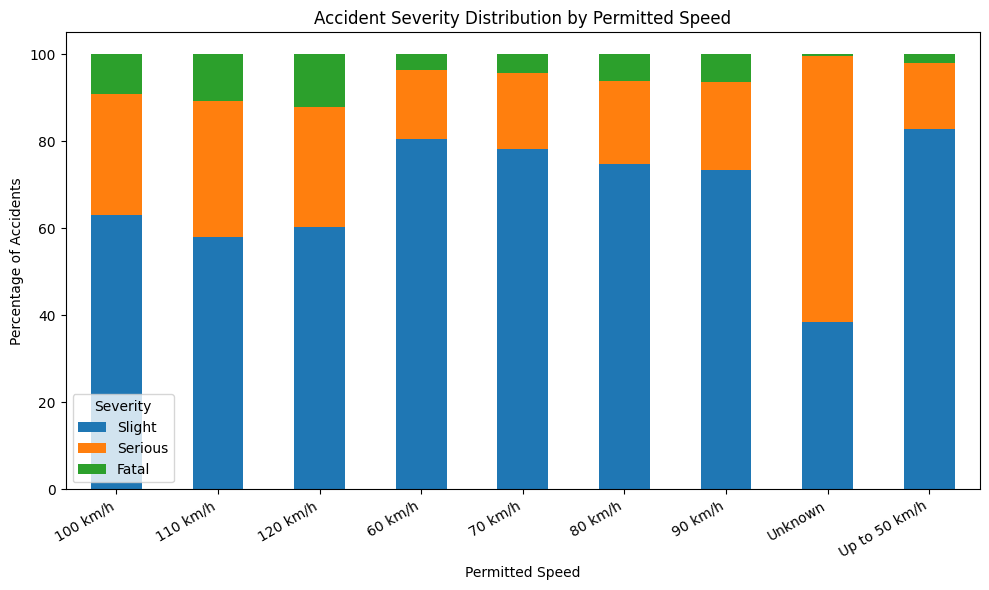

In [28]:
plot_severity_by_feature(
    train_df,
    "MEHIRUT_MUTERET",
    "Permitted Speed"
)

#### Observations

Permitted speed appears to have a clear relationship with accident severity.

In general, higher permitted speeds are associated with a higher proportion of serious and fatal accidents. For example, the severe accident rate increases from approximately 17% for roads with a permitted speed of up to 50 km/h to approximately 42% for roads with a permitted speed of 110 km/h.

The `Unknown` category behaves very differently from the other categories, with a particularly high serious accident rate. This may indicate that `Unknown` is not missing at random and should be investigated before preprocessing.

### SUG_DEREH (Road Type)


In [29]:
severity_summary(train_df, "SUG_DEREH")

,count,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,
"Non-urban, not at intersection",8341,7.36,28.11,64.52,35.48
"Urban, not at intersection",14544,2.42,27.00,70.58,29.42
"Non-urban, at intersection",5284,2.21,15.75,82.04,17.96
"Urban, at intersection",13457,1.46,12.61,85.93,14.07


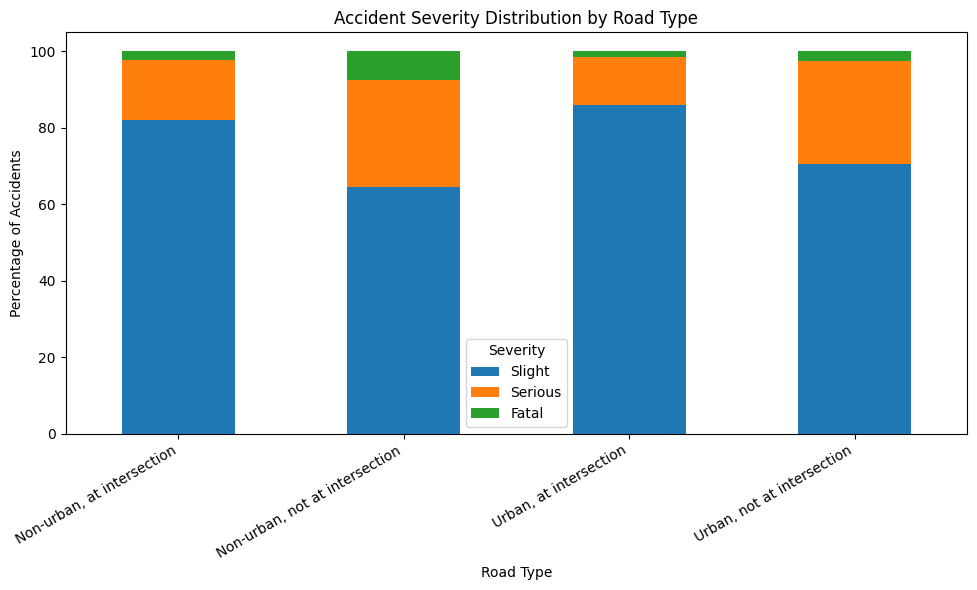

In [30]:
plot_severity_by_feature(
    train_df,
    "SUG_DEREH",
    "Road Type"
)

#### Observations

Road type shows a clear relationship with accident severity.

Non-urban roads have substantially higher serious and fatal accident rates than urban roads.

In addition, accidents that occur away from intersections tend to be more severe than accidents at intersections, both in urban and non-urban areas.

This suggests that `SUG_DEREH` may be an informative feature for severity prediction.

Another thing I want to review is the option to split it to two new features: ROAD_IS_URBAN and ROAD_IS_INTERSECTION

In [31]:
road_type = train_df["SUG_DEREH"].map(
    VALUE_LABELS["SUG_DEREH"]
)

train_df["ROAD_IS_URBAN"] = road_type.isin([
    "Urban, at intersection",
    "Urban, not at intersection"
])

train_df["ROAD_IS_INTERSECTION"] = road_type.isin([
    "Urban, at intersection",
    "Non-urban, at intersection"
])

In [32]:
def summarize_boolean_feature(
    df,
    feature,
    true_label="True",
    false_label="False"
):
    display_values = df[feature].map({
        True: true_label,
        False: false_label
    })

    severity = df["HUMRAT_TEUNA"].map(
        VALUE_LABELS["HUMRAT_TEUNA"]
    )

    analysis_df = pd.DataFrame({
        feature: display_values,
        "severity": severity
    })

    summary = (
        analysis_df
        .groupby(feature)
        .agg(
            count=("severity", "size"),
            fatal_rate=("severity", lambda x: (x == "Fatal").mean() * 100),
            serious_rate=("severity", lambda x: (x == "Serious").mean() * 100),
            slight_rate=("severity", lambda x: (x == "Slight").mean() * 100),
        )
    )

    summary["severe_rate"] = (
        summary["fatal_rate"]
        + summary["serious_rate"]
    )

    return summary.round(2)

In [33]:
urban_summary = summarize_boolean_feature(
    train_df,
    "ROAD_IS_URBAN",
    true_label="Urban",
    false_label="Non-urban"
)

urban_summary

,count,fatal_rate,serious_rate,slight_rate,severe_rate
ROAD_IS_URBAN,,,,,
Non-urban,13625,5.37,23.32,71.32,28.68
Urban,28001,1.96,20.08,77.96,22.04


In [34]:
intersection_summary = summarize_boolean_feature(
    train_df,
    "ROAD_IS_INTERSECTION",
    true_label="At intersection",
    false_label="Not at intersection"
)

intersection_summary

,count,fatal_rate,serious_rate,slight_rate,severe_rate
ROAD_IS_INTERSECTION,,,,,
At intersection,18741,1.67,13.49,84.84,15.16
Not at intersection,22885,4.22,27.41,68.37,31.63


In [35]:
def plot_boolean_feature_severity(
    df,
    feature,
    true_label="True",
    false_label="False",
    title=None
):
    display_values = df[feature].map({
        True: true_label,
        False: false_label
    })

    severity = df["HUMRAT_TEUNA"].map(
        VALUE_LABELS["HUMRAT_TEUNA"]
    )

    severity_distribution = (
        pd.crosstab(
            display_values,
            severity,
            normalize="index"
        ) * 100
    )

    severity_distribution = severity_distribution[
        ["Slight", "Serious", "Fatal"]
    ]

    severity_distribution.plot(
        kind="bar",
        stacked=True,
        figsize=(8, 5)
    )

    plt.title(title or feature)
    plt.xlabel("")
    plt.ylabel("Percentage of Accidents")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

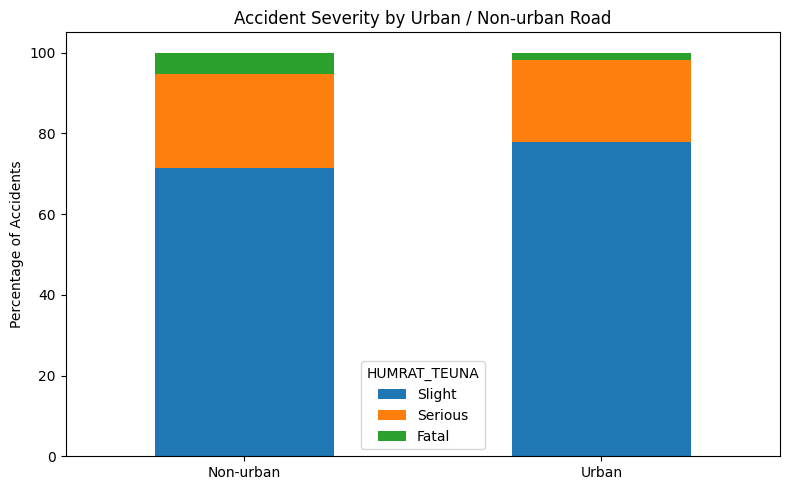

In [36]:
plot_boolean_feature_severity(
    train_df,
    "ROAD_IS_URBAN",
    true_label="Urban",
    false_label="Non-urban",
    title="Accident Severity by Urban / Non-urban Road"
)

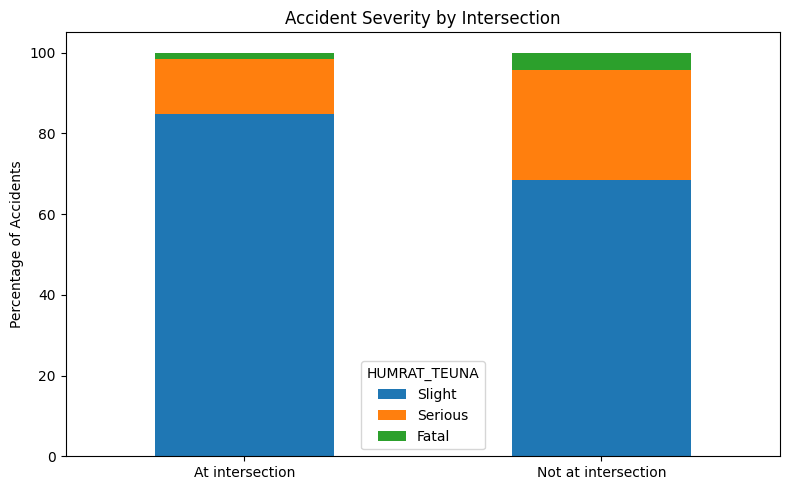

In [37]:
plot_boolean_feature_severity(
    train_df,
    "ROAD_IS_INTERSECTION",
    true_label="At intersection",
    false_label="Not at intersection",
    title="Accident Severity by Intersection"
)

#### Split to new features Observations

Splitting `SUG_DEREH` into two binary features reveals two separate relationships with accident severity.

- Non-urban roads have a substantially higher proportion of serious and fatal accidents than urban roads.
- Accidents occurring outside intersections also tend to be much more severe than accidents at intersections.

The urban/non-urban distinction appears to have a stronger relationship with severity than the intersection distinction.

Both derived features will be kept for modeling.

### HAD_MASLUL (Road Type)
While investigating, I will remove the value 0 (Not applicable - see RAV_MASLUL) since it's data is on the `RAV_MASLUL` feature

In [38]:
feature_distribution(train_df, "HAD_MASLUL")

,count,percentage
HAD_MASLUL,,
Not applicable - see RAV_MASLUL,14711,35.34
Two-way without continuous dividing line,12977,31.18
One-way,6597,15.85
Number of carriageways unknown,4224,10.15
Two-way with continuous dividing line,3117,7.49


In [39]:
severity_summary(
    train_df,
    "HAD_MASLUL",
    exclude_values=[0]
)

,count,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,
Number of carriageways unknown,4224,0.47,61.25,38.28,61.72
Two-way with continuous dividing line,3117,5.65,20.08,74.27,25.73
Two-way without continuous dividing line,12977,3.06,16.65,80.29,19.71
One-way,6597,2.43,16.54,81.04,18.96


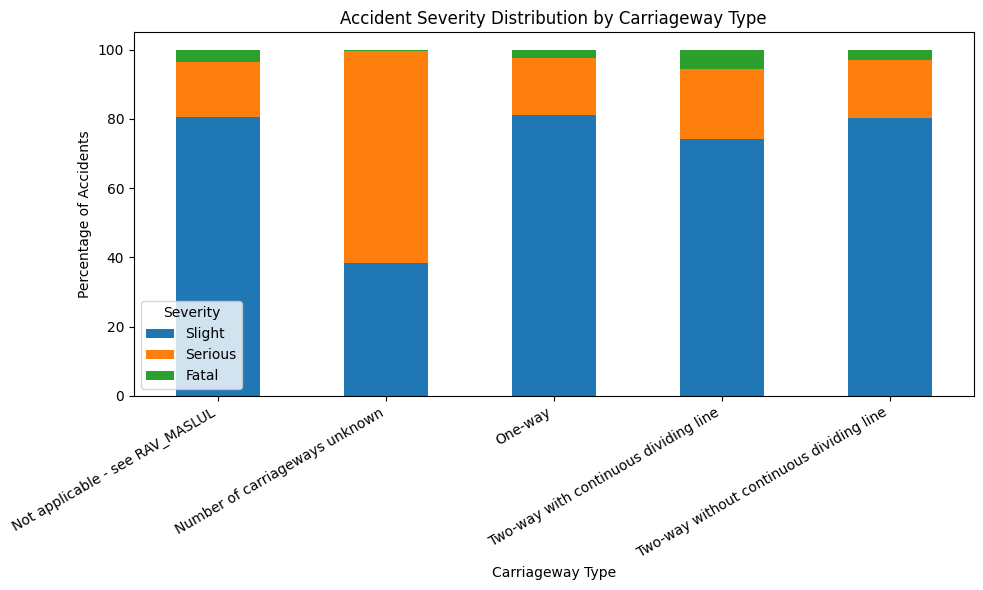

In [40]:
plot_severity_by_feature(
    train_df,
    "HAD_MASLUL",
    "Carriageway Type"
)

#### `HAD_MASLUL` - Observations

According to the CBS codebook, `HAD_MASLUL` and `RAV_MASLUL` are complementary
fields describing the carriageway configuration.

When `HAD_MASLUL` contains the applicable road configuration, `RAV_MASLUL`
is set to `0`. When `RAV_MASLUL` contains the applicable configuration,
`HAD_MASLUL` is set to `0`.

Therefore, the 14,711 records with `HAD_MASLUL = 0` are not missing values
and should not be interpreted as a separate carriageway category. Their
road configuration is described by `RAV_MASLUL`.

Among the applicable `HAD_MASLUL` categories, two-way roads with a continuous
dividing line show a higher serious/fatal accident rate than one-way roads
and two-way roads without a continuous dividing line.

The `Unknown` category is substantially different, with approximately 62%
of accidents classified as serious or fatal. This category should be
preserved and investigated separately.

The next step is to analyze `RAV_MASLUL` and then determine whether the two
fields should be combined into a single carriageway feature.

### RAV_MASLUL

I will remove the value 0, which mean Not applicable - see HAD_MASLUL from the investigation

In [41]:
feature_distribution(train_df, "RAV_MASLUL", exclude_values=[0])

,count,percentage
RAV_MASLUL,,
Built median without safety barrier,8391,57.04
Median with safety barrier,4290,29.16
Median marked with paint,1012,6.88
Other,720,4.89
Unbuilt median,298,2.03


In [42]:
severity_summary(
    train_df,
    "RAV_MASLUL",
    exclude_values=[0]
)

,count,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,
Median with safety barrier,4290,5.71,19.42,74.87,25.13
Unbuilt median,298,3.02,18.12,78.86,21.14
Other,720,2.64,15.28,82.08,17.92
Built median without safety barrier,8391,2.76,14.29,82.95,17.05
Median marked with paint,1012,2.08,13.83,84.09,15.91


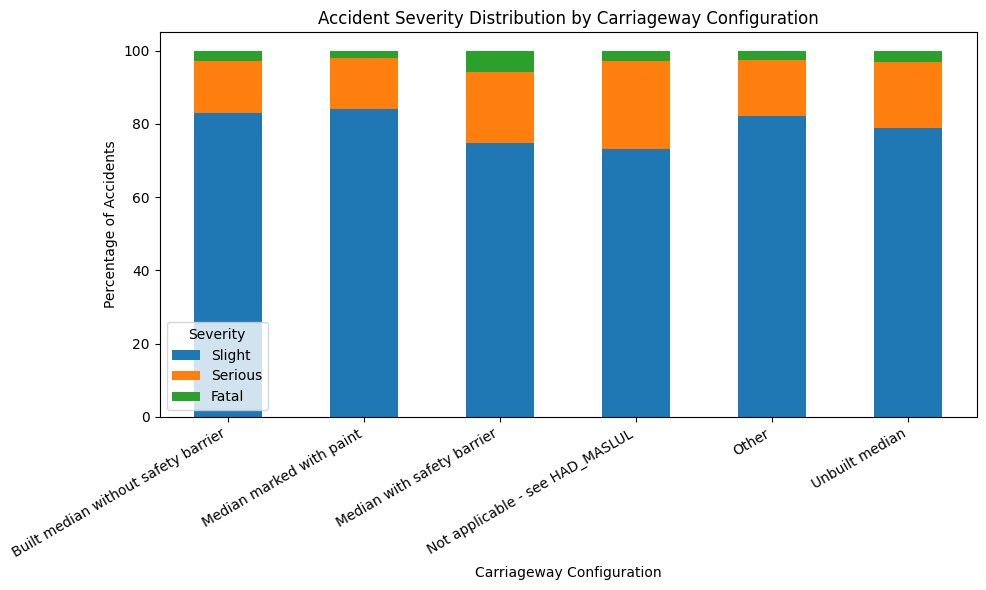

In [43]:
plot_severity_by_feature(
    train_df,
    "RAV_MASLUL",
    "Carriageway Configuration"
)

#### `RAV_MASLUL` - Observations

The multi-carriageway configuration shows differences in accident severity.

Roads with a median safety barrier have the highest serious/fatal accident rate,
at approximately 25%, compared with approximately 17% for built medians without
a safety barrier and 16% for medians marked with paint.

This should not be interpreted as evidence that safety barriers increase accident
severity. The result may be influenced by other road characteristics, such as
permitted speed and whether the road is urban or non-urban.

The `Unbuilt median` category also shows a relatively high severe accident rate,
but contains only 298 observations, so the result should be interpreted cautiously.

### `HAD_MASLUL` and `RAV_MASLUL` - Feature Engineering

`HAD_MASLUL` and `RAV_MASLUL` are complementary fields that together describe the road carriageway configuration.

During feature engineering, they will be combined into two derived features:

- `ROAD_CARRIAGEWAY`: Single / Multi / Unknown
- `ROAD_CARRIAGEWAY_TYPE`: Detailed carriageway configuration

The original fields are kept unchanged during EDA.

During the feature engineering and modeling stages, the derived representation will be evaluated and a decision will be made whether the original `HAD_MASLUL` and `RAV_MASLUL` fields should also be included in the model.

In [44]:
def get_carriageway_type(row):
    if row["HAD_MASLUL"] != 0:
        label = VALUE_LABELS["HAD_MASLUL"].get(row["HAD_MASLUL"])

        if label == "Number of carriageways unknown":
            return "Unknown"

        return f"Single: {label}"

    if row["RAV_MASLUL"] != 0:
        label = VALUE_LABELS["RAV_MASLUL"].get(row["RAV_MASLUL"])
        return f"Multi: {label}"

    return "Unknown"


train_df["ROAD_CARRIAGEWAY_TYPE"] = train_df.apply(
    get_carriageway_type,
    axis=1
)

train_df["ROAD_CARRIAGEWAY_TYPE"].value_counts(dropna=False)

ROAD_CARRIAGEWAY_TYPE
Single: Two-way without continuous dividing line    12977
Multi: Built median without safety barrier           8391
Single: One-way                                      6597
Multi: Median with safety barrier                    4290
Unknown                                              4224
Single: Two-way with continuous dividing line        3117
Multi: Median marked with paint                      1012
Multi: Other                                          720
Multi: Unbuilt median                                 298
Name: count, dtype: int64

In [45]:
def get_road_carriageway(row):
    if row["HAD_MASLUL"] in [1, 2, 3, 4]:
        return "Single"

    if row["RAV_MASLUL"] in [1, 2, 3, 4, 5]:
        return "Multi"

    return "Unknown"

train_df["ROAD_CARRIAGEWAY"] = train_df.apply(
    get_road_carriageway,
    axis=1
)

train_df["ROAD_CARRIAGEWAY"].value_counts()

ROAD_CARRIAGEWAY
Single     22691
Multi      14711
Unknown     4224
Name: count, dtype: int64

### ROHAV (Road Width)


In [46]:
feature_distribution(train_df, "ROHAV", exclude_values=[0])

,count,percentage
ROHAV,,
7 to 10.5 m,14060,39.04
5 to 7 m,11865,32.94
10.5 to 14 m,4756,13.21
Up to 5 m,2936,8.15
Over 14 m,2399,6.66


In [47]:
severity_summary(
    train_df,
    "ROHAV"
)

,count,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,
Unknown,5610,0.78,50.27,48.95,51.05
Over 14 m,2399,5.50,18.13,76.37,23.63
10.5 to 14 m,4756,4.48,17.01,78.51,21.49
7 to 10.5 m,14060,3.78,16.71,79.51,20.49
Up to 5 m,2936,2.21,16.86,80.93,19.07
5 to 7 m,11865,2.47,15.95,81.58,18.42


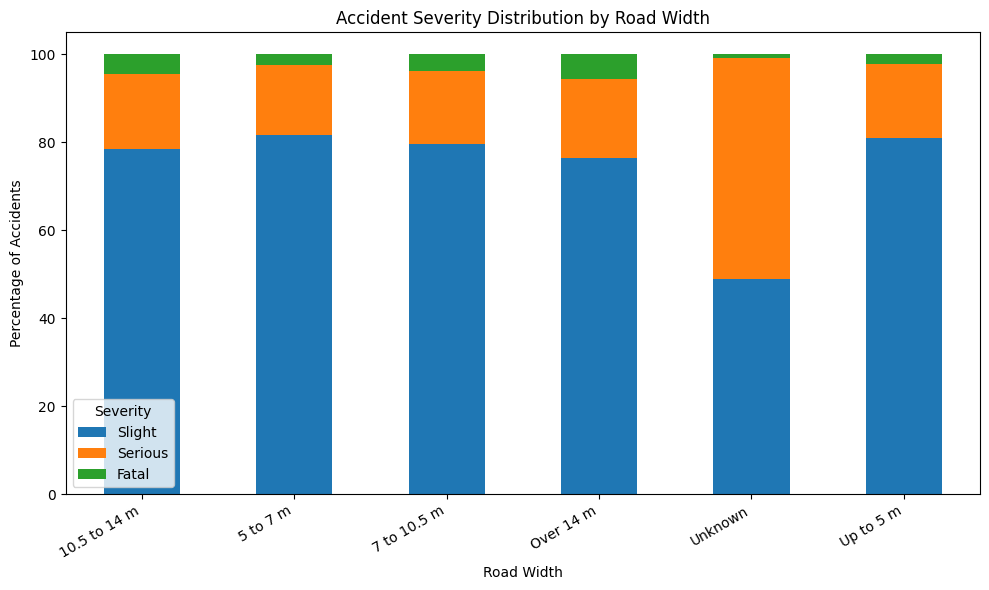

In [48]:
plot_severity_by_feature(
    train_df,
    "ROHAV",
    "Road Width"
)

#### Observations

Road width shows a moderate relationship with accident severity.

In general, wider roads tend to have a somewhat higher proportion of serious and fatal accidents. The severe accident rate increases from approximately 18-19% for narrower roads to approximately 24% for roads wider than 14 meters.

The relationship is present, but it is weaker than the patterns observed for road type and permitted speed.

Wider roads appear to be associated with higher accident severity. One possible explanation is that wider roads may also be associated with higher permitted speeds, which could contribute to more severe outcomes. I will now check the theory.

The `Unknown` category is substantially different, with approximately 51% of accidents classified as serious or fatal. This is consistent with the broader pattern previously observed in other road-related fields, where unknown values tend to occur together and are associated with a distinct subset of accidents.

In [49]:
road_width_speed = pd.crosstab(
    train_df["ROHAV"].map(VALUE_LABELS["ROHAV"]),
    train_df["MEHIRUT_MUTERET"].map(VALUE_LABELS["MEHIRUT_MUTERET"]),
    normalize="index"
) * 100

road_width_speed.round(2)

MEHIRUT_MUTERET,100 km/h,110 km/h,120 km/h,60 km/h,70 km/h,80 km/h,90 km/h,Unknown,Up to 50 km/h
ROHAV,,,,,,,,,
10.5 to 14 m,2.48,1.16,0.76,5.11,11.23,15.39,22.25,0.02,41.61
5 to 7 m,0.30,0.18,0.08,3.31,3.26,6.33,3.08,0.13,83.33
7 to 10.5 m,0.63,0.63,0.14,5.77,7.16,16.74,11.47,0.11,57.35
Over 14 m,2.83,2.88,1.83,4.38,11.17,13.42,25.89,0.08,37.52
Unknown,0.14,0.12,0.12,0.78,1.07,1.76,2.09,75.20,18.70
Up to 5 m,0.07,0.07,0.03,2.52,1.98,2.79,1.98,0.10,90.46


In [50]:
analysis_df = train_df.assign(
    road_width=train_df["ROHAV"].map(VALUE_LABELS["ROHAV"]),
    permitted_speed=train_df["MEHIRUT_MUTERET"].map(
        VALUE_LABELS["MEHIRUT_MUTERET"]
    ),
    severity=train_df["HUMRAT_TEUNA"].map(
        VALUE_LABELS["HUMRAT_TEUNA"]
    )
)

severity_by_width_and_speed = (
    analysis_df
    .groupby(["permitted_speed", "road_width"])
    .agg(
        count=("severity", "size"),
        severe_rate=(
            "severity",
            lambda x: x.isin(["Serious", "Fatal"]).mean() * 100
        )
    )
    .reset_index()
)

severity_by_width_and_speed

,permitted_speed,road_width,count,severe_rate
0,100 km/h,10.5 to 14 m,118,34.745763
1,100 km/h,5 to 7 m,36,19.444444
2,100 km/h,7 to 10.5 m,88,31.818182
3,100 km/h,Over 14 m,68,58.823529
4,100 km/h,Unknown,8,25.000000
5,100 km/h,Up to 5 m,2,0.000000
6,110 km/h,10.5 to 14 m,55,41.818182
7,110 km/h,5 to 7 m,21,14.285714
8,110 km/h,7 to 10.5 m,89,39.325843
9,110 km/h,Over 14 m,69,49.275362


#### Additional Observation

Road width is strongly associated with permitted speed.

Narrower roads are predominantly associated with speed limits of up to 50 km/h, while wider roads have a much larger proportion of 80, 90, 100 and 110 km/h speed limits.

This supports the hypothesis that part of the relationship previously observed between road width and accident severity may be explained by the association between wider roads and higher permitted speeds.

When road width was compared within the same permitted-speed category, the relationship with severity became considerably less consistent.

### TKINUT

In [51]:
feature_distribution(train_df, "TKINUT")

,count,percentage
TKINUT,,
No defect,34794,83.59
Unknown,6268,15.06
Damaged road surface,402,0.97
Poor shoulders,111,0.27
Poor shoulders and damaged road surface,51,0.12


In [52]:
severity_summary(train_df, "TKINUT")

,count,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,
Poor shoulders and damaged road surface,51,7.84,45.10,47.06,52.94
Unknown,6268,1.26,46.12,52.62,47.38
Poor shoulders,111,9.91,27.03,63.06,36.94
Damaged road surface,402,6.72,26.62,66.67,33.33
No defect,34794,3.33,16.53,80.15,19.85


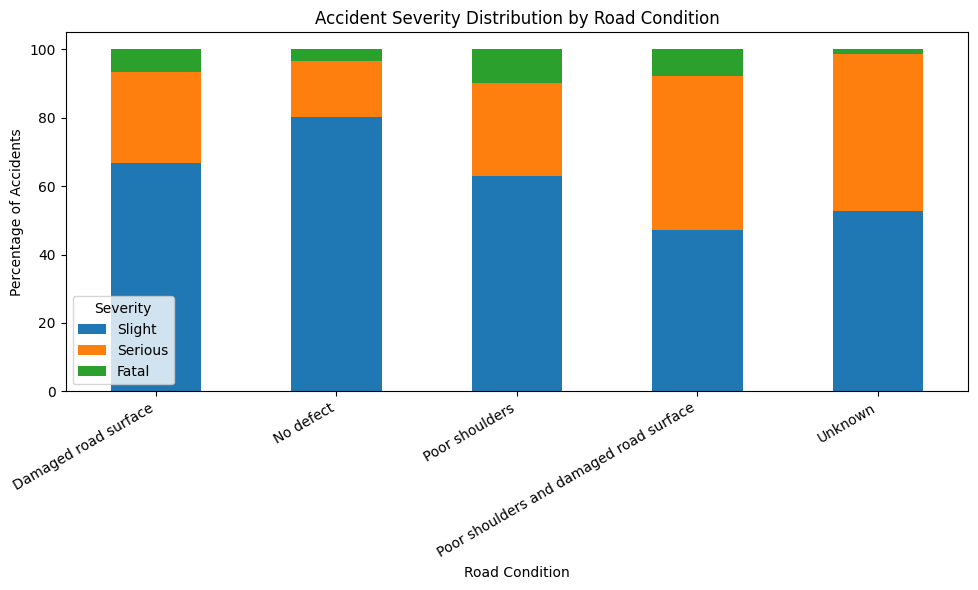

In [53]:
plot_severity_by_feature(
    train_df,
    "TKINUT",
    "Road Condition"
)

#### Observations

Road condition appears to be associated with accident severity.

Accidents recorded on roads with no reported defects have a severe accident rate of approximately 20%, while categories representing road defects show higher severe accident rates.

However, the defect categories contain relatively few observations, especially `Poor shoulders` and `Poor shoulders and damaged road surface`, so their severity rates should be interpreted cautiously.

The `Unknown` category again shows a substantially higher severe accident rate.
This is consistent with the pattern observed in other road-related features, where unknown values appear to represent a distinct subset of accidents rather than random missing information.

Since the individual defect categories contain relatively few observations, I will create a derived feature called `ROAD_DEFECT` that combines all defect categories into a single `Defect` category, while keeping `No defect` and `Unknown` as separate categories.

In [58]:
train_df["ROAD_DEFECT"] = (
    train_df["TKINUT"]
    .map(VALUE_LABELS["TKINUT"])
    .map(lambda x:
        "Unknown" if x == "Unknown"
        else "No defect" if x == "No defect"
        else "Defect"
    )
)

train_df["ROAD_DEFECT"].value_counts(dropna=False)

ROAD_DEFECT
No defect    34794
Unknown       6268
Defect         564
Name: count, dtype: int64

In [60]:
road_defect_summary = (
    train_df.assign(
        severity=train_df["HUMRAT_TEUNA"].map(
            VALUE_LABELS["HUMRAT_TEUNA"]
        )
    )
    .groupby("ROAD_DEFECT")
    .agg(
        count=("severity", "size"),
        fatal_rate=("severity", lambda x: (x == "Fatal").mean() * 100),
        serious_rate=("severity", lambda x: (x == "Serious").mean() * 100),
        slight_rate=("severity", lambda x: (x == "Slight").mean() * 100),
    )
)

road_defect_summary["severe_rate"] = (
    road_defect_summary["fatal_rate"]
    + road_defect_summary["serious_rate"]
)

road_defect_summary.round(2)

,count,fatal_rate,serious_rate,slight_rate,severe_rate
ROAD_DEFECT,,,,,
Defect,564,7.45,28.37,64.18,35.82
No defect,34794,3.33,16.53,80.15,19.85
Unknown,6268,1.26,46.12,52.62,47.38


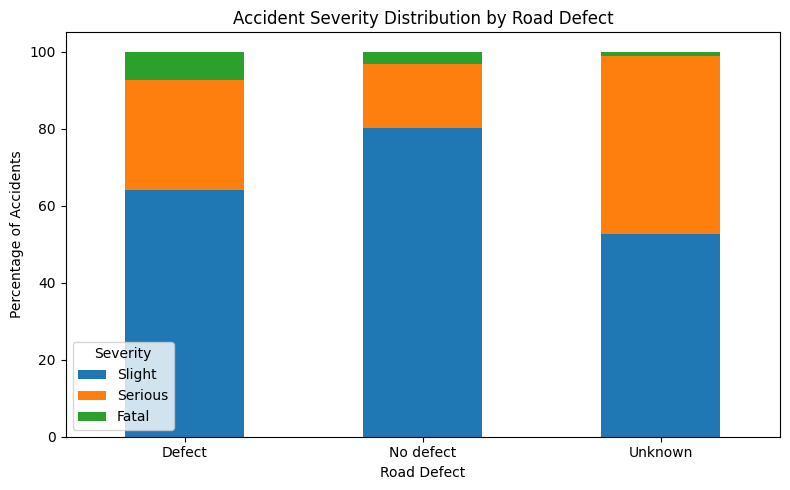

In [61]:
severity_by_road_defect = (
    pd.crosstab(
        train_df["ROAD_DEFECT"],
        train_df["HUMRAT_TEUNA"].map(
            VALUE_LABELS["HUMRAT_TEUNA"]
        ),
        normalize="index"
    ) * 100
)

severity_by_road_defect = severity_by_road_defect[
    ["Slight", "Serious", "Fatal"]
]

severity_by_road_defect.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Accident Severity Distribution by Road Defect")
plt.xlabel("Road Defect")
plt.ylabel("Percentage of Accidents")
plt.xticks(rotation=0)
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

The derived `ROAD_DEFECT` feature shows a clear difference in accident severity.

Accidents associated with a road defect have a severe accident rate of approximately 36%, compared with approximately 20% for roads with no reported defects.

This suggests that the presence of a road defect is associated with higher accident severity.

The `Unknown` category remains substantially different, with a severe accident rate of approximately 47%, consistent with the pattern observed in other road-related features.

### SIMUN_TIMRUR (Road Markings / Traffic Signs Condition)

In [62]:
feature_distribution(
    train_df,
    "SIMUN_TIMRUR"
)

,count,percentage
SIMUN_TIMRUR,,
No defect,32739,78.65
Unknown,5230,12.56
Traffic sign not required,2409,5.79
Road markings defective or missing,815,1.96
Traffic signs defective or missing,433,1.04


In [63]:
severity_summary(
    train_df,
    "SIMUN_TIMRUR"
)

,count,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,
Unknown,5230,0.80,53.96,45.24,54.76
Traffic sign not required,2409,6.48,23.25,70.28,29.72
Road markings defective or missing,815,4.05,18.65,77.30,22.70
No defect,32739,3.19,15.89,80.92,19.08
Traffic signs defective or missing,433,1.15,15.01,83.83,16.17


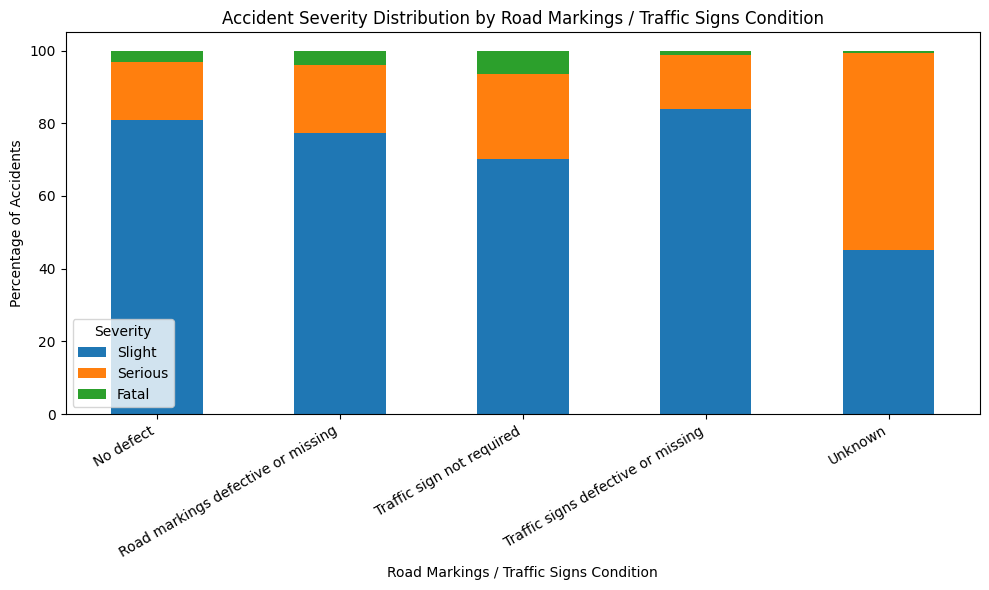

In [64]:
plot_severity_by_feature(
    train_df,
    "SIMUN_TIMRUR",
    "Road Markings / Traffic Signs Condition"
)

#### Observations

There is no substantial difference in accident severity between `No defect` and the categories representing defective or missing road markings and traffic signs.

When the two defect categories are considered together, their severe accident rate is close to that of the `No defect` category.

However, `Traffic sign not required` shows a higher severe accident rate, while the `Unknown` category again represents a substantially different group.

Therefore, there is currently no strong evidence that marking or traffic-sign defects themselves provide a meaningful severity signal.

`SIMUN_TIMRUR` will be kept for now and evaluated during modeling, where its additional predictive value can be assessed before deciding whether to remove it.

### TEURA (Lighting Conditions)

In [65]:
feature_distribution(
    train_df,
    "TEURA"
)

,count,percentage
TEURA,,
Normal daylight,23870,57.34
"Night, lighting operational",9282,22.30
"Night, unknown",3736,8.98
"Day, unknown",3383,8.13
"Night, no lighting",617,1.48
Lighting exists but defective or not operating,321,0.77
Twilight,241,0.58
Limited visibility due to weather,102,0.25
"Night, proper lighting with limited visibility",36,0.09


In [66]:
severity_summary(
    train_df,
    "TEURA"
)

,count,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,
"Night, defective lighting with limited visibility",22,22.73,40.91,36.36,63.64
"Day, unknown",3383,0.68,56.10,43.22,56.78
"Night, no lighting",617,13.13,31.60,55.27,44.73
Lighting exists but defective or not operating,321,11.21,24.61,64.17,35.83
"Night, unknown",3736,1.77,33.00,65.23,34.77
"Night, no lighting with limited visibility",16,12.50,12.50,75.00,25.00
Twilight,241,7.05,17.84,75.10,24.90
"Night, proper lighting with limited visibility",36,2.78,19.44,77.78,22.22
"Night, lighting operational",9282,4.22,17.09,78.69,21.31


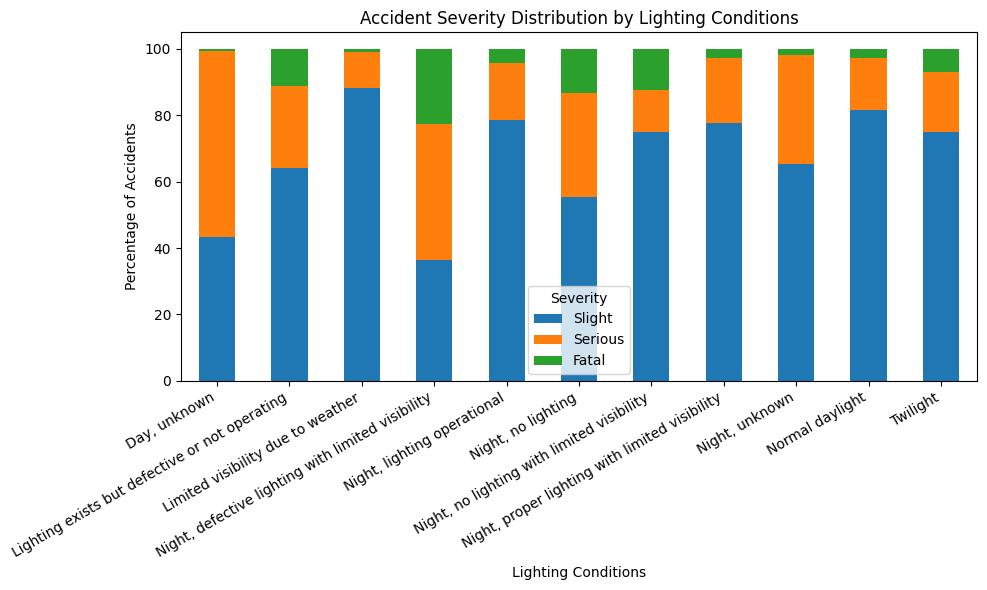

In [67]:
plot_severity_by_feature(
    train_df,
    "TEURA",
    "Lighting Conditions"
)

#### Observations

Lighting conditions appear to be associated with accident severity.

Accidents under normal lighting conditions show relatively lower severe accident rates:
- `Normal daylight`: approximately 18%
- `Night, lighting operational`: approximately 21%

Several categories representing problematic lighting or limited visibility show higher severe accident rates. However, some of these categories contain very few observations, so they should be interpreted cautiously.

The `Day, unknown` and `Night, unknown` categories again show substantially higher severe accident rates, consistent with the pattern observed in other road-related features.

Since day/night information is already represented by `YOM_LAYLA`, I will not create another derived feature for time of day based on `TEURA`.

Instead, I will evaluate a derived feature representing problematic lighting or visibility conditions.

In [76]:
def map_lighting_issue(value):
    label = VALUE_LABELS["TEURA"].get(value)

    if label in [
        "Day, unknown",
        "Night, unknown"
    ]:
        return "Unknown"

    if label in [
        "Lighting exists but defective or not operating",
        "Night, defective lighting with limited visibility",
        "Night, no lighting",
        "Night, no lighting with limited visibility",
        "Night, proper lighting with limited visibility",
        "Limited visibility due to weather",
    ]:
        return "Issue"

    return "No issue"


train_df["LIGHTING_ISSUE"] = train_df["TEURA"].map(
    map_lighting_issue
)

In [85]:
feature_distribution(
    train_df,
    "LIGHTING_ISSUE",
    skip_validation=True
)

,LIGHTING_ISSUE,count,percentage
0,No issue,33393,80.22
1,Unknown,7119,17.10
2,Issue,1114,2.68


In [ ]:
severity_summary(
    train_df,
    "LIGHTING_ISSUE",
    skip_validation=True
)

,count,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,
Unknown,7119,1.25,43.98,54.77,45.23
Issue,1114,11.31,27.20,61.49,38.51
No issue,33393,3.19,16.07,80.74,19.26


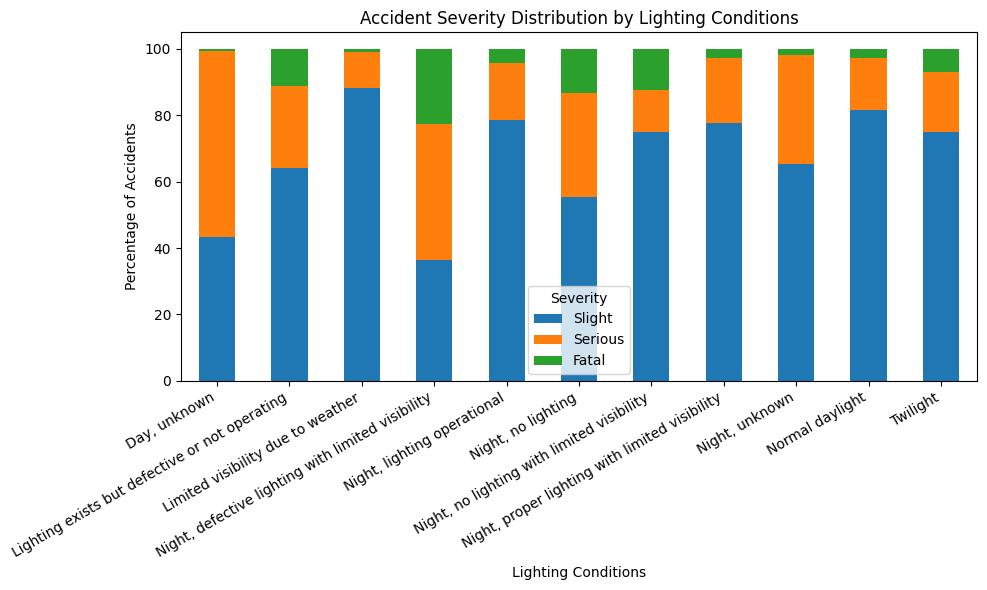

In [ ]:
plot_severity_by_feature(
    train_df,
    "LIGHTING_ISSUE",
    "Lighting Conditions Issue"
)

#### Feature Engineering Observations

The derived `LIGHTING_ISSUE` feature shows a clear relationship with accident severity.

Accidents with a lighting or visibility issue have a severe accident rate of approximately 39%, compared with approximately 19% when no issue is reported.

The `Unknown` category remains substantially different, with a severe accident rate of approximately 45%.

This suggests that `LIGHTING_ISSUE` may provide a useful predictive signal and will be considered as a candidate feature for the model.

### MEZEG_AVIR (Weather Conditions)

In [86]:
feature_distribution(
    train_df,
    "MEZEG_AVIR"
)

,MEZEG_AVIR,count,percentage
0,Clear,34603,83.13
1,Unknown,5215,12.53
2,Rainy,1543,3.71
3,Hot and dry,148,0.36
4,Other,79,0.19
5,Foggy,38,0.09


In [87]:
severity_summary(
    train_df,
    "MEZEG_AVIR"
)

,count,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,
Unknown,5215,0.94,53.37,45.70,54.30
Other,79,7.59,24.05,68.35,31.65
Foggy,38,5.26,21.05,73.68,26.32
Clear,34603,3.36,16.64,80.00,20.00
Hot and dry,148,2.70,16.89,80.41,19.59
Rainy,1543,3.69,13.42,82.89,17.11


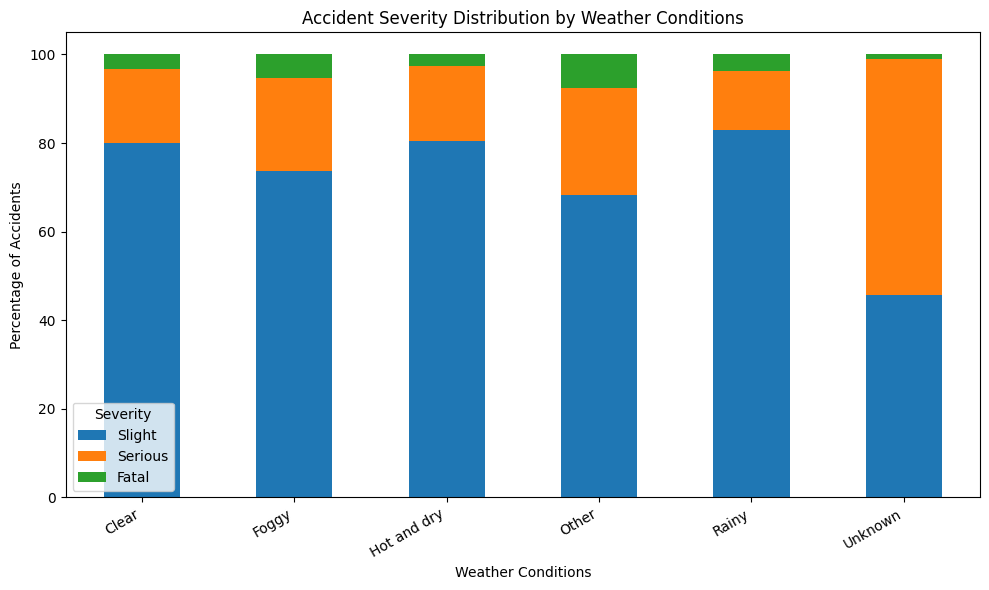

In [88]:
plot_severity_by_feature(
    train_df,
    "MEZEG_AVIR",
    "Weather Conditions"
)

#### Observations

After excluding `Unknown` and `Other`, weather conditions do not appear to have a strong relationship with accident severity.

`Clear`, `Hot and dry`, and `Rainy` conditions show relatively similar severe accident rates. `Foggy` conditions show a somewhat higher severe accident rate, but this category contains only 38 observations, so the result should be interpreted cautiously.

Most accidents, approximately 83%, occurred under clear weather conditions. `Unknown` and `Other` account for approximately 13% of the data, while adverse weather conditions such as rain and fog represent only a small proportion of the dataset.

The `Unknown` category again shows a substantially different severity distribution, consistent with the pattern observed in several other features.

Overall, `MEZEG_AVIR` appears to provide limited direct information about accident severity and will be kept for now, but considered a candidate for removal during modeling.

### PNE_KVISH (Road Surface Condition)

In [89]:
feature_distribution(
    train_df,
    "PNE_KVISH"
)

,PNE_KVISH,count,percentage
0,Dry,34634,83.20
1,Unknown,4519,10.86
2,Wet,2128,5.11
3,Sand or gravel on road,180,0.43
4,Other,123,0.30
5,Covered with mud,23,0.06
6,Covered with fuel,19,0.05


In [90]:
severity_summary(
    train_df,
    "PNE_KVISH"
)

,count,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,
Unknown,4519,0.53,58.93,40.54,59.46
Other,123,8.13,34.15,57.72,42.28
Covered with mud,23,13.04,26.09,60.87,39.13
Sand or gravel on road,180,4.44,22.78,72.78,27.22
Covered with fuel,19,5.26,21.05,73.68,26.32
Dry,34634,3.33,16.58,80.09,19.91
Wet,2128,3.76,14.29,81.95,18.05


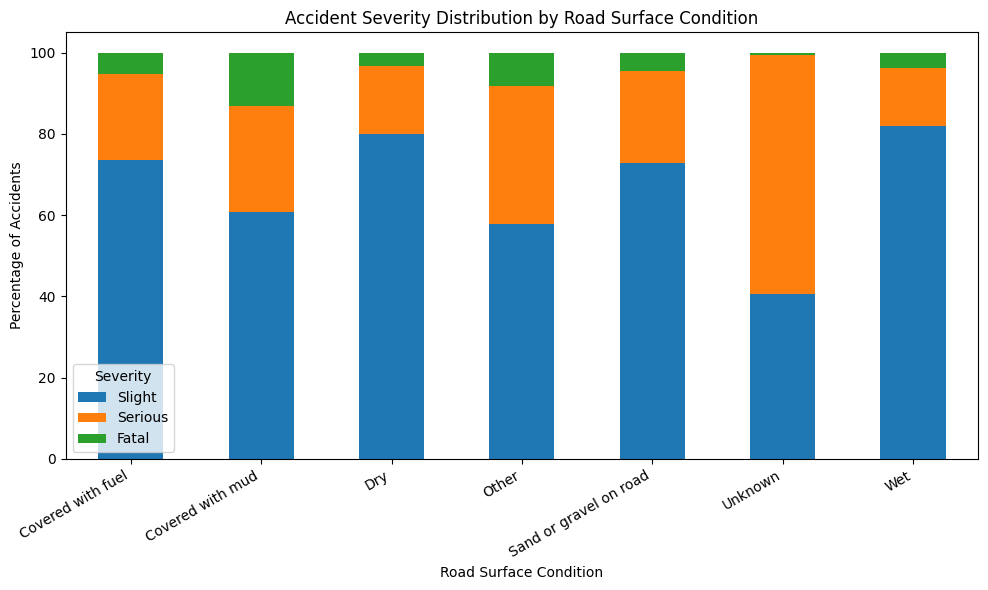

In [91]:
plot_severity_by_feature(
    train_df,
    "PNE_KVISH",
    "Road Surface Condition"
)

#### Observations

As in several other features, `Unknown` shows a substantially different severity distribution and will be treated separately.

Most accidents occurred on a dry road surface, approximately 83%, followed by wet road surfaces at approximately 5%. The remaining specific surface conditions are relatively rare.

There is little difference in accident severity between `Dry` and `Wet` road conditions, with severe accident rates of approximately 20% and 18%, respectively.

Some less common road-surface conditions, such as mud, sand or gravel, and fuel on the road, show higher severe accident rates. However, these categories contain relatively few observations when considered individually.

To reduce sparsity, I will evaluate a derived `ROAD_SURFACE` feature with the following categories:
- `Dry`
- `Wet`
- `Surface issue`
- `Other`
- `Unknown`

The `Surface issue` category will combine mud, sand or gravel, and fuel on the road.

In [99]:
def map_road_surface_condition(value):
    label = VALUE_LABELS["PNE_KVISH"].get(value)

    if label == "Unknown":
        return "Unknown"

    if label == "Dry":
        return "Dry"

    if label == "Wet":
        return "Wet"

    if label in [
        "Covered with mud",
        "Sand or gravel on road",
        "Covered with fuel",
    ]:
        return "Surface issue"

    return "Other"


train_df["ROAD_SURFACE_CONDITION"] = (
    train_df["PNE_KVISH"]
    .map(map_road_surface_condition)
)

In [102]:
train_df["ROAD_SURFACE_CONDITION"].value_counts(dropna=False)

ROAD_SURFACE_CONDITION
Dry              34634
Unknown           4519
Wet               2128
Surface issue      222
Other              123
Name: count, dtype: int64

In [107]:
severity_summary(
    train_df,
    "ROAD_SURFACE_CONDITION",
    skip_validation=True
)

,count,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,
Unknown,4519,0.53,58.93,40.54,59.46
Other,123,8.13,34.15,57.72,42.28
Surface issue,222,5.41,22.97,71.62,28.38
Dry,34634,3.33,16.58,80.09,19.91
Wet,2128,3.76,14.29,81.95,18.05


#### Feature Engining Observations

The derived `ROAD_SURFACE_CONDITION` feature provides a more compact and interpretable representation than the original `PNE_KVISH` feature.

The grouped `Surface issue` category has a severe accident rate of approximately 28%, compared with approximately 20% for `Dry` and 18% for `Wet`.

The `Unknown` and `Other` categories remain substantially different and are kept separate.

Overall, `ROAD_SURFACE_CONDITION` appears to preserve the meaningful signal in `PNE_KVISH` while reducing sparsity in the rare surface-condition categories.

This feature is therefore a good candidate to replace `PNE_KVISH` during the feature engineering and modeling stages.

### SUG_EZEM (Type of Stationary Object Struck)

In [112]:
(
    object_rows["SUG_TEUNA"]
    .map(VALUE_LABELS["SUG_TEUNA"])
    .value_counts()
)

SUG_TEUNA
Collision with stationary object        1530
Front-to-side collision                  252
Rollover                                 150
Head-on collision                         71
Front-to-rear collision                   65
Skidding                                  60
Side-to-side collision                    56
Collision with pedestrian                 47
Leaving roadway or mounting sidewalk      45
Collision with parked vehicle             31
Other                                     29
Fall from moving vehicle                   2
Rear-to-side collision                     1
Rear-to-front collision                    1
Name: count, dtype: int64

In [109]:
stationary_object_df = train_df[
    train_df["SUG_TEUNA"] == 8
].copy()

In [110]:
feature_distribution(
    stationary_object_df,
    "SUG_EZEM"
)

,SUG_EZEM,count,percentage
0,Vehicle safety barrier,517,28.80
1,Other,303,16.88
2,Utility pole,282,15.71
3,Unknown,265,14.76
4,Tree,179,9.97
5,Structure,145,8.08
6,Traffic sign / signboard,91,5.07
7,Bridge and protective structures,8,0.45
8,Barrel,5,0.28


In [108]:
feature_distribution(
    train_df,
    "SUG_EZEM"
)

,SUG_EZEM,count,percentage
0,Unknown,39286,94.38
1,Vehicle safety barrier,834,2.00
2,Other,436,1.05
3,Utility pole,398,0.96
4,Traffic sign / signboard,241,0.58
5,Tree,220,0.53
6,Structure,196,0.47
7,Bridge and protective structures,9,0.02
8,Barrel,6,0.01


`SUG_EZEM` is documented as being relevant to accidents classified as`Collision with stationary object` (`SUG_TEUNA = 8`).

However, the dataset contains non-unknown `SUG_EZEM` values for several other accident types as well.

Approximately two thirds of the accidents with a recorded stationary object are classified as `Collision with stationary object`, while the remaining records are distributed across other accident types such as front-to-side collisions, rollovers, and head-on collisions.

Therefore, I will not restrict the analysis of `SUG_EZEM` only to `SUG_TEUNA = 8`.

Instead, the recorded object type will be analyzed wherever it is available, while taking into account that the large `Unknown` group may include cases where this field is not applicable rather than truly unknown.

In [113]:
known_object_df = train_df[
    train_df["SUG_EZEM"].map(VALUE_LABELS["SUG_EZEM"]) != "Unknown"
].copy()

feature_distribution(
    known_object_df,
    "SUG_EZEM"
)

,SUG_EZEM,count,percentage
0,Vehicle safety barrier,834,35.64
1,Other,436,18.63
2,Utility pole,398,17.01
3,Traffic sign / signboard,241,10.30
4,Tree,220,9.40
5,Structure,196,8.38
6,Bridge and protective structures,9,0.38
7,Barrel,6,0.26


In [114]:
severity_summary(
    known_object_df,
    "SUG_EZEM"
)

,count,fatal_rate,serious_rate,slight_rate,severe_rate
feature,,,,,
Other,436,11.24,28.67,60.09,39.91
Vehicle safety barrier,834,9.59,26.62,63.79,36.21
Tree,220,6.36,25.91,67.73,32.27
Structure,196,9.69,21.94,68.37,31.63
Utility pole,398,6.03,23.87,70.10,29.90
Traffic sign / signboard,241,4.15,19.92,75.93,24.07
Bridge and protective structures,9,11.11,0.00,88.89,11.11
Barrel,6,0.00,0.00,100.00,0.00


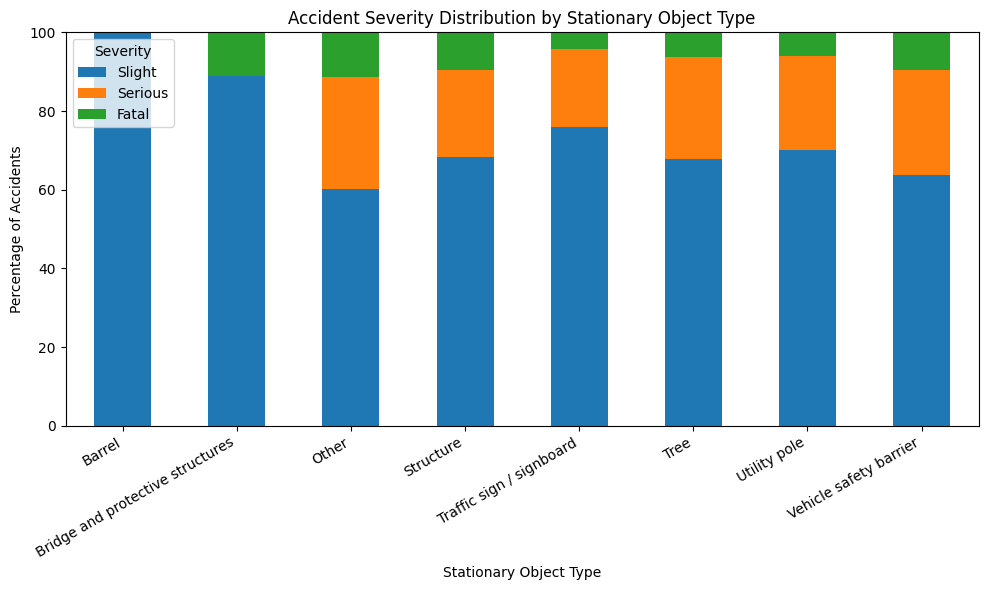

In [115]:
plot_severity_by_feature(
    known_object_df,
    "SUG_EZEM",
    "Stationary Object Type"
)

#### Observations

Among accidents where a stationary object is recorded, the type of object appears to be associated with accident severity.

`Other` and `Vehicle safety barrier` have the highest severe accident rates, at approximately 40% and 36%, respectively. `Tree`, `Structure`, and `Utility pole` also show relatively high severe accident rates.

`Traffic sign / signboard` has a lower severe accident rate of approximately 24%.

The `Bridge and protective structures` and `Barrel` categories contain very few observations, so their severity rates should not be interpreted as reliable patterns.

Overall, `SUG_EZEM` appears to contain useful information when an object is recorded.
However, since an object type is available for only a small fraction of all accidents, its final representation should be evaluated during feature engineering.